In [50]:
#!pip install nixtla

In [1]:

import pandas as pd
from nixtla import NixtlaClient
nixtla_client = NixtlaClient(api_key = 'nixak-fdeb395c1c38014d4292173c77382d77112264957706fd4bfd4ba3ea8d27da243ee0fa406f4a8105')
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

In [2]:
## Load the data from file/files

In [3]:
#load data from cities

# 2. Read historic electricity demand data
df = pd.read_csv('nl_monthly.csv')
df

,utc_timestamp,NL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00+00:00,392469.583333
1,2015-02-01 00:00:00+00:00,336715.625000
2,2015-03-01 00:00:00+00:00,353968.541667
3,2015-04-01 00:00:00+00:00,319292.750000
4,2015-05-01 00:00:00+00:00,313571.083333
5,2015-06-01 00:00:00+00:00,315609.458333
6,2015-07-01 00:00:00+00:00,325886.958333
7,2015-08-01 00:00:00+00:00,319762.666667
8,2015-09-01 00:00:00+00:00,323992.708333
9,2015-10-01 00:00:00+00:00,350157.250000


## Select training data based on Scenario

In [19]:
# Select data for training # 
fra = '2015'
til = '2019'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData

,utc_timestamp,NL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00+00:00,392469.583333
1,2015-02-01 00:00:00+00:00,336715.625000
2,2015-03-01 00:00:00+00:00,353968.541667
3,2015-04-01 00:00:00+00:00,319292.750000
4,2015-05-01 00:00:00+00:00,313571.083333
5,2015-06-01 00:00:00+00:00,315609.458333
6,2015-07-01 00:00:00+00:00,325886.958333
7,2015-08-01 00:00:00+00:00,319762.666667
8,2015-09-01 00:00:00+00:00,323992.708333
9,2015-10-01 00:00:00+00:00,350157.250000


In [20]:
len(trainData)

48

## Validation data selection based on scenario

In [21]:
# Select data for validation # 
fra = '2019'
til = '2020'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,actual
48,2019-01-01 00:00:00+00:00,445540.166667
49,2019-02-01 00:00:00+00:00,391549.916667
50,2019-03-01 00:00:00+00:00,417876.916667
51,2019-04-01 00:00:00+00:00,373638.916667
52,2019-05-01 00:00:00+00:00,376835.625000
53,2019-06-01 00:00:00+00:00,360165.958333
54,2019-07-01 00:00:00+00:00,382177.208333
55,2019-08-01 00:00:00+00:00,377412.833333
56,2019-09-01 00:00:00+00:00,373280.958333
57,2019-10-01 00:00:00+00:00,408227.666667


In [22]:
len(validData)

12

## Forcasting wsith timeGPT

In [23]:
# 3. Forecast the next 24 hours
# First, ensure your DataFrame has the required column names
# Nixtla typically expects 'ds' for the timestamp column and 'y' for the target variable

# Assuming trainData has a datetime column with a different name (e.g., 'date' or 'timestamp')
# Rename it to match Nixtla's expected format
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'y'})

# Now try forecasting again
fcst_df = nixtla_client.forecast(trainData, 
                                 h=len(validData), 
                                 freq='MS',
                                 model='timegpt-1-long-horizon')

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


In [24]:
print("Train end:", trainData['ds'].max())
print("Forecast start:", fcst_df['ds'].min())
print("Valid start:", validData['ds'].min())

Train end: 2018-12-01 00:00:00+00:00
Forecast start: 2019-01-01 00:00:00+00:00
Valid start: 2019-01-01 00:00:00+00:00


In [25]:
fcst_df

,ds,TimeGPT
0,2019-01-01 00:00:00+00:00,438382.78
1,2019-02-01 00:00:00+00:00,404510.70
2,2019-03-01 00:00:00+00:00,412200.10
3,2019-04-01 00:00:00+00:00,382627.50
4,2019-05-01 00:00:00+00:00,387773.12
5,2019-06-01 00:00:00+00:00,385450.75
6,2019-07-01 00:00:00+00:00,390590.47
7,2019-08-01 00:00:00+00:00,388018.28
8,2019-09-01 00:00:00+00:00,386542.10
9,2019-10-01 00:00:00+00:00,406416.53


## Merge forecast n actual

In [29]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')
result

,ds,TimeGPT,actual
0,2019-01-01 00:00:00+00:00,438382.78,445540.166667
1,2019-02-01 00:00:00+00:00,404510.70,391549.916667
2,2019-03-01 00:00:00+00:00,412200.10,417876.916667
3,2019-04-01 00:00:00+00:00,382627.50,373638.916667
4,2019-05-01 00:00:00+00:00,387773.12,376835.625000
5,2019-06-01 00:00:00+00:00,385450.75,360165.958333
6,2019-07-01 00:00:00+00:00,390590.47,382177.208333
7,2019-08-01 00:00:00+00:00,388018.28,377412.833333
8,2019-09-01 00:00:00+00:00,386542.10,373280.958333
9,2019-10-01 00:00:00+00:00,406416.53,408227.666667


In [30]:
print(fcst_df.columns)
print(validData.columns)

Index(['ds', 'TimeGPT'], dtype='object')
Index(['ds', 'actual'], dtype='object')


## Metrics calculation (rRMSE and rMAE)

In [31]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['TimeGPT']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['TimeGPT'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.0311 rMAE: 0.0274 


## Comparison of GPT vs Actual

In [32]:
city = 'Monthly The Netherland TimeGPT'

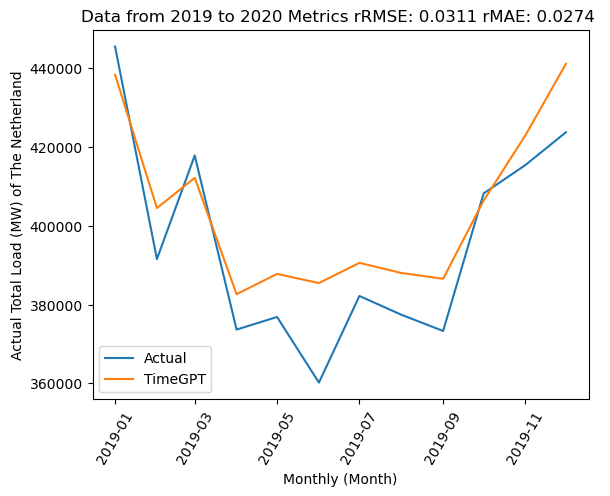

In [34]:
import matplotlib.pyplot as plt
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['TimeGPT'],label='TimeGPT')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Monthly (Month)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of The Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
